# Exercise E3

Write a notebook to produce the following maps

The Antarctic continent and the Southern Ocean starting from 60°S
The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo

In [2]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

# Exercise 1 : South Pole

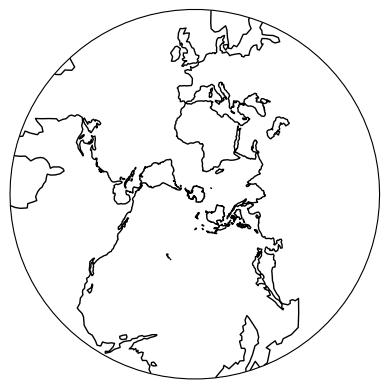

In [5]:
plt.figure()
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.coastlines()

## Exercise 2

[Location(Athens, Municipality of Athens, Regional Unit of Central Athens, Attica, 105 57, Greece, (37.9755648, 23.7348324, 0.0)), Location(Algiers, Sidi M'Hamed District, Algiers, 16000, Algeria, (36.7729333, 3.0588445, 0.0)), Location(Malta, (35.9311442, 14.3951627, 0.0)), Location(Gibraltar, (36.1285933, -5.3474761, 0.0))]


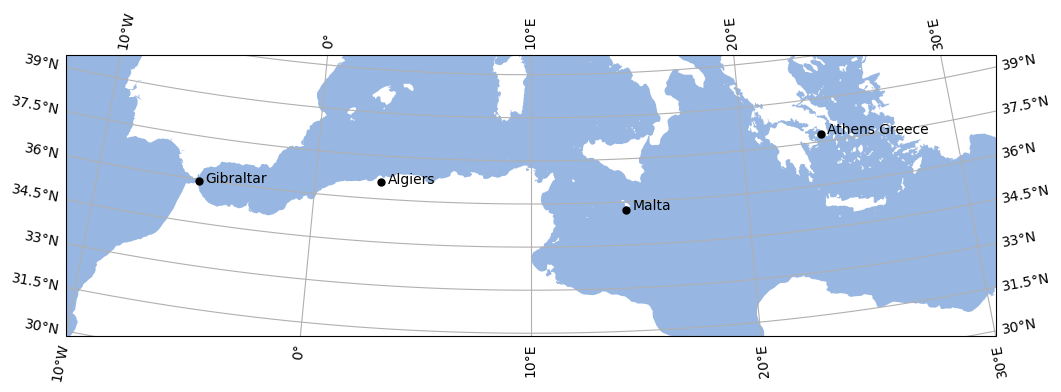

In [6]:
geolocator = Nominatim(user_agent='educational')
# a map of the Mediterranean, with a few places
extent = [-10, 30, 30, 40]
central_lon = np.mean(extent[:2])
central_lat = np.mean(extent[2:])

place = ['Athens Greece','Algiers','Malta','Gibraltar']
address = []
for p in place:
    loc = geolocator.geocode(p,language="en")
    address.append(loc)
print(address)

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.AlbersEqualArea(central_lon, central_lat))
ax.set_extent(extent)
ax.add_feature(cfeature.OCEAN)
ax.gridlines(draw_labels=True)
for p in range(len(place)):
    ax.plot(address[p].longitude,address[p].latitude,'ko',markersize=5,transform=ccrs.Geodetic())
    ax.text(address[p].longitude+0.3,address[p].latitude,place[p],transform=ccrs.Geodetic())